# Probing Tryout

Same 20 pairs and layer 6 as in the steering notebook, but now a logistic regression learns the direction. Does its w point where d points, and does it steer?


In [1]:
# Setup: GPT-2 small, the 20 minimal pairs from the steering notebook, one mean residual vector per
# sentence at blocks.6.hook_resid_pre (BOS dropped), and the difference-in-means direction d as the
# reference. Expectation: same numbers as in 03, residual norm 83.0, gap 6.21.
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2", device="mps")
torch.manual_seed(0)

pairs = [
    ("The movie was absolutely wonderful.", "The movie was absolutely terrible."),
    ("I loved every minute of the show.", "I hated every minute of the show."),
    ("The food at that place was delicious.", "The food at that place was disgusting."),
    ("What a fantastic day this has been.", "What a horrible day this has been."),
    ("Her new book is a delight to read.", "Her new book is a chore to read."),
    ("The hotel room was clean and cozy.", "The hotel room was dirty and cramped."),
    ("This is the best coffee I have ever had.", "This is the worst coffee I have ever had."),
    ("The concert last night was amazing.", "The concert last night was awful."),
    ("Our trip to the coast was perfect.", "Our trip to the coast was miserable."),
    ("The service here is friendly and quick.", "The service here is rude and slow."),
    ("I am so happy with how this turned out.", "I am so disappointed with how this turned out."),
    ("The garden looks beautiful this spring.", "The garden looks hideous this spring."),
    ("He gave a brilliant talk at the meeting.", "He gave a dull talk at the meeting."),
    ("The kids had a great time at the park.", "The kids had a rotten time at the park."),
    ("That was a lovely dinner with old friends.", "That was a painful dinner with old friends."),
    ("The new phone works smoothly.", "The new phone works poorly."),
    ("Everyone enjoyed the party last weekend.", "Everyone disliked the party last weekend."),
    ("The weather has been glorious all week.", "The weather has been dreadful all week."),
    ("The team played superbly in the final.", "The team played dismally in the final."),
    ("My first day at the new job was exciting.", "My first day at the new job was depressing."),
]
pos_sentences = [p for p, _ in pairs]
neg_sentences = [n for _, n in pairs]

LAYER = 6

def sentence_resid(sentence, layer):
    # [positions, d_model] at the layer input, BOS dropped
    name = f"blocks.{layer}.hook_resid_pre"
    _, cache = model.run_with_cache(model.to_tokens(sentence), names_filter=name)
    return cache[name][0, 1:]

def direction(pos, neg):
    diff = pos.mean(0) - neg.mean(0)
    return diff / diff.norm(), diff.norm().item()

pos_resid = [sentence_resid(s, LAYER) for s in pos_sentences]
neg_resid = [sentence_resid(s, LAYER) for s in neg_sentences]
pos_acts = torch.stack([r.mean(0) for r in pos_resid])  # [20, d_model], one vector per sentence
neg_acts = torch.stack([r.mean(0) for r in neg_resid])
resid_norm = torch.cat(pos_resid + neg_resid).norm(dim=-1).mean().item()
d, gap = direction(pos_acts, neg_acts)
print(f"layer {LAYER}: per-position residual norm {resid_norm:.1f}, |mean(pos) - mean(neg)| = {gap:.2f}")


/Users/Brose/dev/private_repos/mechinterp_xai/.venv/lib/python3.13/site-packages/transformer_lens/config/hooked_transformer_config.py:354: UserWarning: MPS backend may produce silently incorrect results (PyTorch 2.13.0). Set TRANSFORMERLENS_ALLOW_MPS=1 to suppress this warning. See: https://github.com/TransformerLensOrg/TransformerLens/issues/1178
  warn_if_mps(self.device)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
layer 6: per-position residual norm 83.0, |mean(pos) - mean(neg)| = 6.21


Same numbers as in 03, norm 83.0 and gap 6.21, so the probe works on exactly the vectors d was built from.


In [2]:
# Probe: logistic regression with L2 on the raw 40 vectors, leave-one-pair-out. No standardizing,
# so w lives in the same space as d. Per fold: held-out predictions and the margin (x_pos - x_neg) . w_hat,
# the same quantity as for d in 03 (mean 5.64, min 3.29). Expectation: 40 of 40, margin close to d's.
X = torch.cat([pos_acts, neg_acts]).cpu().numpy()  # [40, d_model], positives first
y = np.array([1] * len(pairs) + [0] * len(pairs))
pair_id = np.tile(np.arange(len(pairs)), 2)  # sentence i and i + 20 form pair i

def fit_probe(X, y, C):
    # high max_iter: the data are separable, weakly regularized fits converge slowly
    clf = LogisticRegression(C=C, max_iter=10_000).fit(X, y)
    w = clf.coef_[0]
    return w / np.linalg.norm(w), clf

def held_out_probe(X, y, C):
    # fit on 19 pairs, score the 2 held-out sentences, margin along the unit probe direction
    correct, margins = 0, []
    for i in range(len(pairs)):
        train = pair_id != i
        w_hat, clf = fit_probe(X[train], y[train], C)
        correct += (clf.predict(X[~train]) == y[~train]).sum()
        margins.append((X[i] - X[i + len(pairs)]) @ w_hat)
    return correct, np.array(margins)

C = 1.0
correct, margins = held_out_probe(X, y, C)
print(f"C = {C}: {correct} of {len(y)} held-out sentences correct, "
      f"margin mean {margins.mean():.2f}, min {margins.min():.2f}, "
      f"{(margins > 0).sum()} of {len(pairs)} pairs ordered correctly")


C = 1.0: 40 of 40 held-out sentences correct, margin mean 5.56, min 3.27, 20 of 20 pairs ordered correctly


40 of 40 held out and a margin of 5.56 against 5.64 for d: by these two numbers the probe at C = 1 is indistinguishable from d. Before reading anything into that, the control task shows what the probe achieves on labels that carry no sentiment.


In [3]:
# Control task (Hewitt & Liang): same probe, same protocol, but each pair's labels are swapped at random,
# so the labels carry no sentiment while balance and pair structure stay intact. Held-out accuracy is what
# the probe achieves on its own. Expectation: around 20 of 40, training accuracy still 1.0 (separable).
rng = np.random.default_rng(0)
control = []
for _ in range(10):
    flip = rng.random(len(pairs)) < 0.5  # which pairs swap their labels
    y_control = np.where(flip[pair_id], 1 - y, y)
    correct, _ = held_out_probe(X, y_control, C)
    train_acc = fit_probe(X, y_control, C)[1].score(X, y_control)
    control.append((correct, train_acc))
control = np.array(control)
print(f"control task, C = {C}: held-out {control[:, 0].mean():.1f} of {len(y)} correct on average "
      f"(min {control[:, 0].min():.0f}, max {control[:, 0].max():.0f}), training accuracy {control[:, 1].mean():.2f}")


control task, C = 1.0: held-out 19.4 of 40 correct on average (min 15, max 25), training accuracy 1.00


19.4 of 40 held out with training accuracy 1.0: on labels without sentiment the probe is at chance while still fitting everything, so the 40 of 40 above is information in the activations, not probe capacity.


In [4]:
# How much of w is d? Probe on all 40 vectors for a range of C, cosine of the unit probe direction to d,
# next to the held-out numbers at the same C. Expectation: cos near 1 for small C (strong L2, the gradient
# at zero points along the mean difference), falling towards 0.5-0.8 for large C (max-margin direction).
d_np = d.cpu().numpy()
Cs = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
probes = {}
print(f"{'C':>8} {'cos(w, d)':>10} {'held-out':>9} {'margin mean':>12} {'margin min':>11} {'|w| raw':>9}")
for C_ in Cs:
    w_hat, clf = fit_probe(X, y, C_)
    correct, margins = held_out_probe(X, y, C_)
    probes[C_] = w_hat
    print(f"{C_:>8g} {w_hat @ d_np:>10.3f} {correct:>6d}/40 {margins.mean():>12.2f} {margins.min():>11.2f} "
          f"{np.linalg.norm(clf.coef_[0]):>9.4f}")


       C  cos(w, d)  held-out  margin mean  margin min   |w| raw
   1e-05      1.000     39/40         5.64        3.29    0.0006
  0.0001      1.000     40/40         5.65        3.29    0.0061
   0.001      0.999     40/40         5.65        3.28    0.0561
    0.01      0.992     40/40         5.65        3.27    0.3217
     0.1      0.979     40/40         5.62        3.27    0.8532
       1      0.965     40/40         5.56        3.27    1.5154
      10      0.954     39/40         5.52        3.27    2.2587
     100      0.980     39/40         5.53        3.24    3.0928


cos(w, d) never drops below 0.95 over seven orders of magnitude of C. At small C it is 1.000 as derived; at large C it does not move towards a max-margin direction the way I expected. On these 40 minimal pairs the probe and the mean difference are almost the same direction, and held-out and margin barely change with C, so neither number can tell w from d. Next: w at C = 1 and its part orthogonal to d through the dose sweep from 03, next to d and a random vector.


In [5]:
# Steering toolkit, copied from 03 so both notebooks measure the same thing: adjective logit difference
# on ten neutral prompts, next-token loss on ten factual sentences, alpha * vector added at
# blocks.6.hook_resid_pre on every position except BOS. Expectation: baseline 1.89 and loss 3.99 as in 03.
import matplotlib.pyplot as plt

prompts = [
    "The movie was", "I thought the food was", "Overall, the hotel was", "My day at work was",
    "The concert last night was", "Honestly, the book was", "The weather today is",
    "The service at the restaurant was", "The game yesterday was", "Her presentation was",
]
pos_words = ["good", "great", "excellent", "nice", "enjoyable", "pleasant", "impressive", "outstanding"]
neg_words = ["bad", "boring", "poor", "disappointing", "unpleasant", "mediocre", "lousy", "pathetic"]
pos_ids = torch.tensor([model.to_single_token(" " + w) for w in pos_words]).to("mps")
neg_ids = torch.tensor([model.to_single_token(" " + w) for w in neg_words]).to("mps")

def last_logits(prompt, fwd_hooks=()):
    logits = model.run_with_hooks(model.to_tokens(prompt), fwd_hooks=list(fwd_hooks))
    return logits[0, -1]

def logit_diff(fwd_hooks=()):
    # one number per prompt: positive adjectives minus negative ones at the next-token position
    return torch.tensor([(l[pos_ids].mean() - l[neg_ids].mean()).item()
                         for l in (last_logits(p, fwd_hooks) for p in prompts)])

neutral_sentences = [
    "The train to Hamburg leaves from platform four every hour.",
    "Water boils at one hundred degrees Celsius at sea level.",
    "The library closes at eight on weekdays and at six on Saturdays.",
    "Copper conducts electricity better than aluminium.",
    "The meeting has been moved to the second floor conference room.",
    "Most of the city's buses run on natural gas.",
    "The recipe calls for two eggs and a cup of flour.",
    "The river flows north before it reaches the coast.",
    "Her office is next to the elevator on the third floor.",
    "The museum was built in the nineteenth century.",
]
neutral_tokens = [model.to_tokens(s) for s in neutral_sentences]

def neutral_loss(fwd_hooks=()):
    # mean next-token loss over all positions, averaged over the sentences
    return torch.tensor([model.run_with_hooks(t, return_type="loss", fwd_hooks=list(fwd_hooks)).item()
                         for t in neutral_tokens]).mean()

def sweep_loss(vector, layer, norm):
    name = f"blocks.{layer}.hook_resid_pre"
    return torch.stack([neutral_loss([(name, add_direction(vector, c * norm))]) for c in coefficients])

def add_direction(vector, alpha):
    def hook(resid, hook):
        resid[:, 1:] += alpha * vector  # leave BOS alone, it is the attention sink
        return resid
    return hook

coefficients = [-1, -0.75, -0.5, -0.35, -0.25, -0.15, -0.1, -0.05, 0,
                0.05, 0.1, 0.15, 0.25, 0.35, 0.5, 0.75, 1]

def sweep_logit_diff(vector, layer, norm):
    name = f"blocks.{layer}.hook_resid_pre"
    return torch.stack([logit_diff([(name, add_direction(vector, c * norm))]).mean()
                        for c in coefficients])

def plot_curves(curves, ylabel, baseline_value=None):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for label, values in curves.items():
        ax.plot(coefficients, values.tolist(), marker="o", ms=4, label=label)
    if baseline_value is not None:
        ax.axhline(baseline_value, color="grey", lw=1, ls="--", label="no steering")
    ax.set_xlabel("dose c (fraction of mean residual norm)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

baseline = logit_diff()
baseline_loss = neutral_loss()
print(f"baseline logit difference {baseline.mean():.2f}, baseline loss {baseline_loss:.2f}")


baseline logit difference 1.89, baseline loss 3.99


Baselines match 03, 1.89 and 3.99.


cos(w, d) = 0.965, orthogonal part has length 0.263 before normalising
                       logit difference                                         loss                      
     c            d   w (C = 1)      w_perp      random              d   w (C = 1)      w_perp      random
 -1.00        -0.86       -0.73        1.35        1.00           5.35        5.40        5.87        5.77
 -0.50        -0.64       -0.63        1.71        1.47           4.28        4.27        4.42        4.47
 -0.25        -0.04       -0.01        2.01        1.84           4.00        4.00        4.11        4.13
 -0.10         0.57        0.59        1.97        1.91           3.97        3.97        4.02        4.02
  0.10         3.41        3.29        1.81        1.83           4.04        4.03        3.99        3.99
  0.25         5.05        4.72        1.74        1.70           4.18        4.16        4.06        4.04
  0.50         6.63        6.16        1.65        1.59           4.68   

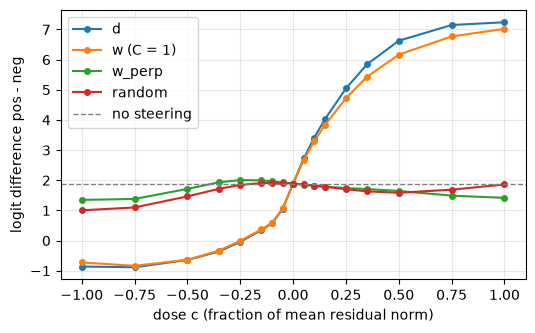

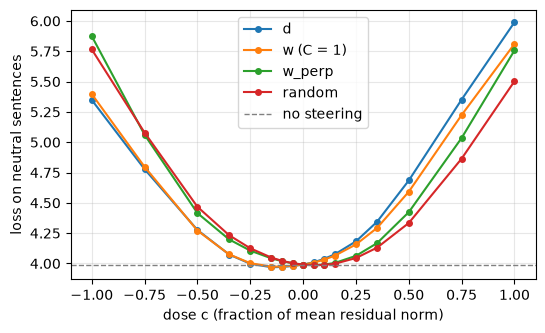

In [6]:
# Four directions through the same sweep: d, the probe w at C = 1, w_perp (the part of w orthogonal to d,
# unit length: what the probe picked up beyond the mean difference), and the norm-matched random vector
# from 03 as the reference for "no direction at all". Expectation: w on top of d in both plots; w_perp flat
# on the metric with a loss like the random vector's.
w = torch.tensor(probes[1], dtype=d.dtype, device=d.device)
w_perp = w - (w @ d) * d
print(f"cos(w, d) = {(w @ d).item():.3f}, orthogonal part has length {w_perp.norm().item():.3f} before normalising")
w_perp = w_perp / w_perp.norm()

torch.manual_seed(1)
r = torch.randn(model.cfg.d_model)  # drawn on CPU so the draw does not depend on the MPS generator
r = (r / r.norm()).to("mps")

directions = {"d": d, "w (C = 1)": w, "w_perp": w_perp, "random": r}
metric_curves = {k: sweep_logit_diff(v, LAYER, resid_norm) for k, v in directions.items()}
loss_curves = {k: sweep_loss(v, LAYER, resid_norm) for k, v in directions.items()}

names = list(directions)
show = [-1, -0.5, -0.25, -0.1, 0.1, 0.25, 0.5, 1]
print(f"{'':>6} {'logit difference':^48}   {'loss':^48}")
print(f"{'c':>6} " + "".join(f"{n:>12}" for n in names) + "   " + "".join(f"{n:>12}" for n in names))
for c in show:
    i = coefficients.index(c)
    print(f"{c:6.2f} " + "".join(f"{metric_curves[n][i]:12.2f}" for n in names)
          + "   " + "".join(f"{loss_curves[n][i]:12.2f}" for n in names))
plot_curves(metric_curves, "logit difference pos - neg", baseline.mean().item())
plot_curves(loss_curves, "loss on neutral sentences", baseline_loss.item())


w sits on d in both plots, a touch weaker at positive doses, which is what 0.965 of the dose should do. w_perp moves the metric the same way in both signs and by no more than the random vector, and it costs the same loss: what the probe picked up beyond the mean difference is push size, not a direction the model answers to. Last, the layer scan.


In [7]:
# Extra: the same probe protocol (C = 1, leave-one-pair-out) at every layer's resid_pre, with cos to that
# layer's d, to see where sentiment is linearly readable. One cached forward pass per sentence.
# Expectation: readable early already (the sentiment token's embedding carries it), margins growing with depth.
def all_layer_acts(sentence):
    # [layers, d_model]: mean over positions without BOS, at the input of every block
    _, cache = model.run_with_cache(model.to_tokens(sentence), names_filter=lambda n: n.endswith("hook_resid_pre"))
    return torch.stack([cache[f"blocks.{l}.hook_resid_pre"][0, 1:].mean(0) for l in range(model.cfg.n_layers)])

acts = torch.stack([all_layer_acts(s) for s in pos_sentences + neg_sentences])  # [40, layers, d_model]
print(f"{'layer':>5} {'held-out':>9} {'margin mean':>12} {'margin min':>11} {'cos(w, d)':>10}")
for l in range(model.cfg.n_layers):
    X_l = acts[:, l].cpu().numpy()
    correct, margins = held_out_probe(X_l, y, C)
    w_l, _ = fit_probe(X_l, y, C)
    d_l, _ = direction(acts[:len(pairs), l], acts[len(pairs):, l])
    print(f"{l:>5} {correct:>6d}/40 {margins.mean():>12.2f} {margins.min():>11.2f} {w_l @ d_l.cpu().numpy():>10.3f}")


layer  held-out  margin mean  margin min  cos(w, d)
    0     39/40         0.17        0.08      0.998
    1     37/40         2.15        0.85      0.952
    2     38/40         2.38        0.99      0.945
    3     37/40         2.69        1.25      0.950
    4     38/40         3.79        1.93      0.956
    5     38/40         4.43        2.79      0.956
    6     40/40         5.56        3.27      0.965
    7     39/40         6.93        3.53      0.950
    8     37/40         8.11        3.79      0.937
    9     37/40         9.42        4.06      0.919
   10     36/40        10.81        4.35      0.899
   11     35/40        11.71        4.43      0.860


Readable from layer 0 on, the token embeddings alone order 39 of 40. From there the paired margin grows tenfold while held-out accuracy falls to 35 of 40 at layer 11: every pair stays ordered along w, but whole pairs drift past the threshold. Pairs cancel what a sentence is about, single sentences do not, so in late layers sentiment is a consistent direction but not a separable property of the sentence mean. Caveat: C = 1 at every layer while the residual norm triples, so late layers are effectively less regularized, which also explains the falling cosine.

## What I take from this

On minimal pairs the probe and the mean difference are the same direction, cos 0.95 or better at any regularization, and everything the probe adds on top steers like a random vector. The gap Marks and Tegmark report between probes and mass-mean did not show up here, not because probes steer well but because the pairs left the probe nothing else to pick up. Held-out accuracy and paired margin answer different questions, and only the margin carries over to steering. Forty sentences, one seed, one layer for the sweep: orientation, not statistics.
